In [1]:
import os

os.environ["TENGRI_HOST_DEVICES"] = "4"  # four CPU devices, one per chain

# Quickstart

A star-forming galaxy observed in 12 broadband filters from GALEX, SDSS, 2MASS, and WISE (ultraviolet through near-infrared) is fitted using Hamiltonian Monte Carlo on a differentiable JAX forward model. This example is deliberately minimal, demonstrating how fast the JIT-compiled forward model and its gradients are. The model uses a double power-law star formation history (SFH) that rises for 10 billion years, peaks about 3 Gyr before the epoch of observation, and then plateaus with ongoing star formation today. Dust attenuation follows a single-component Calzetti screen, nebular emission is baked into the stellar population synthesis grid, stellar metallicity is free to vary, and redshift is fixed at z = 0.05. The SFH shape parameters (alpha, beta, tau_gyr, log_total_mass) are free, the formation epoch is pinned at 13.1 Gyr lookback, and dust V-band optical depth and stellar metallicity are free, giving six free parameters total. See `02_sed_anatomy.py` for a panchromatic model with dust infrared re-emission, photoionized nebular emission, active galactic nucleus, and intergalactic medium absorption enabled.

In [2]:
# Shared notebook setup (see notebooks/_setup.py): quiets the framework notices
# that do not change the science, and loads the SSP grid.
from _setup import FIG_DIR, effective_wavelengths_um, quiet

quiet()

# Re-enable BakedInNebularWarning for this notebook: the baked-in SSP is the
# notebook's headline modeling assumption and the warning signals the frozen
# logU/logZ_gas assumptions to users.
import warnings

warnings.filterwarnings("default", message=".*BakedInBackend.*")

# Notebook-specific: we pair the wNE SSP with baked-in nebular, as intended.
warnings.filterwarnings("ignore", message=".*wNE.*")

from pathlib import Path

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np

import tengri
from tengri import (
    citations,
    cosmology,
    Data,
    DEFAULT,
    Fixed,
    ForwardModel,
    FREE,
    generate_mock,
    Observation,
    Photometry,
    plot,
    SEDModel,
    Uniform,
    WavePrecomp,
)
from tengri.utils.conversions import lnu_to_fnu

plot.setup_style()

C_POST, C_TRUTH, C_DATA = "#3a76d9", "0.15", "#c3372a"

## Stellar library and observation

We use an FSPS-generated SSP grid with nebular emission baked in at log(U) = −3.0 and solar gas-phase metallicity (Z_gas/Z_sun = 1.0). Stellar metallicity is free to vary; gas-phase metallicity is fixed by the grid. These are independent parameters, so the nebular contribution does not respond to fitted stellar metallicity. The code marks this assumption by emitting a `BakedInNebularWarning` on fit start.

In [3]:
SSP_NAME = "prsc_miles_chabrier_wNE"
ssp = tengri.load_ssp(SSP_NAME, download=True)

FILTERS = [
    "galex_fuv",
    "galex_nuv",
    "sdss_u",
    "sdss_g",
    "sdss_r",
    "sdss_i",
    "sdss_z",
    "2mass_j",
    "2mass_h",
    "2mass_ks",
    "wise_w1",
    "wise_w2",
]
obs = Observation(photometry=Photometry.from_names(FILTERS))

## Build the model

The model has a double power-law SFH with single-component Calzetti dust attenuation (V-band optical depth τ_V free), baked-in nebular emission, free stellar metallicity, and redshift fixed at z = 0.05: six free parameters. The double power-law has four free shape parameters (alpha, beta, tau_gyr, log_total_mass) that control whether the SFR rises, peaks, and plateaus while remaining star-forming at the present epoch. The formation epoch, `age_gyr`, is pinned at 13.1 Gyr lookback, the age of the universe at z = 0.05 (formation at the Big Bang), following the convention of BAGPIPES. Pinning the formation epoch removes a strong (age, tau, alpha) degeneracy from the posterior. Infrared dust re-emission, full photoionized nebular grids, and active galactic nucleus components are shown in `02_sed_anatomy.py`.

A single Calzetti screen reddens the entire stellar population uniformly. This simplicity makes the model suitable for a quickstart demonstration, prioritizing interpretability and speed over the realism of a stratified interstellar medium.

In [4]:
sed_model = SEDModel.build(
    ssp_data=ssp,
    observation=obs,
    approx=WavePrecomp(),
    sfh={"type": "dpl", "all_params": FREE, "age_gyr": 13.1},  # formation at the Big Bang
    dust_attenuation={
        "type": "single_component",
        "law": "calzetti",
        "tau_v": Uniform(0.0, 4.0),
    },
    neb={"type": "ssp"},
    met={"logzsol": Uniform(-2.0, 0.2)},
    redshift=Fixed(0.05),
)

# The model that gets fitted. `ForwardModel` pairs the SED with the instrument
# that observed it; the observation is inherited from the SED, so there is
# nothing to re-declare here.
forward = ForwardModel.build(sed=sed_model)

print(sed_model.summary())
citations.print_citations(sed_model)

Model  SFH: dpl
──────────────────────────────────────────────────────────────────
  SSP grid:    15 Z × 93 ages × 5994 λ [91–100000000 Å]
  Filters:     12 bands
  Redshift:    0.0500 (fixed)
  Dtype:       float64
  Fast path:   photometry LUT
  Components:  nebular=ssp

  Pipeline (3 components):
    1. stellar        [sfh_model=dpl, metallicity_model=delta, n_grid=256]
    2. nebular        [backend=baked_in]
    3. dust_attenuation [law=calzetti]

  Parameters:  6 free
──────────────────────────────────────────────────────────────────
Please cite the following when publishing results that use tengri:

  [1] Cooray et al. (2026, Paper I) ; SED fitting framework — methods paper (this package)
       {tengri: Differentiable SED fitting with Information-Field-Theory star formation history priors. I. Framework and mock recovery}

  [2] Bradbury et al. (2018) ; Autodiff framework and XLA compiler integration
       {JAX}: composable transformations of {P}ython+{N}um{P}y programs
       

## Mock observation

The truth is an explicit double power-law: star formation rises for 10 billion years, peaks about 3 Gyr in the past, and then plateaus with the galaxy still forming stars at about 97% of its peak rate. The double power-law turns over at cosmic time T = τ·(β/α)^(1/(α+β)) after formation. With formation pinned at the Big Bang, α = 0.5, β = 2.0, and τ = 5.8 Gyr place the turnover 3 Gyr before the epoch of observation. The shallow falling slope (small α) permits the plateau. The function `generate_mock` returns the noiseless model fluxes, Gaussian noise at the requested signal-to-noise ratio, and a single noisy realization.

In [5]:
key = jax.random.PRNGKey(6)
_, key_mock, key_fit = jax.random.split(key, 3)

truth = {
    "sfh_dpl_alpha": 0.5,  # falling slope: shallow => plateau after the peak
    "sfh_dpl_beta": 2.0,  # rising slope: SFR grows as T^2 at early times
    "sfh_dpl_tau_gyr": 5.8,  # places the turnover at lookback ~3 Gyr
    "sfh_dpl_log_total_mass": 10.0,
    "dust_tau_v": 0.3,
    "met_logzsol": -0.3,
}

# Verify the intended shape: star-forming, peak ~3 Gyr ago, plateau to today
pred_truth = sed_model.predict(truth)
ssfr_truth = float(pred_truth.ssfr)
assert ssfr_truth > 1e-11, (
    f"Truth is not star-forming: sSFR = {ssfr_truth:.3e} /yr (need > 1e-11 /yr)"
)

state_truth = sed_model.predict_state(truth)
sfr_grid = np.asarray(state_truth.derived["sfr_history"])
t_lbt_grid = np.asarray(state_truth.derived["sfh_grid_lbt_yr"])
sfr_current = sfr_grid[np.argmin(np.abs(t_lbt_grid))]
assert sfr_current > 0.0, f"SFR at present is not positive: {sfr_current:.3e} Msun/yr"

# Peak lookback time ~3 Gyr, and a genuine plateau: SFR today within 70% of peak
lbt_peak_gyr = t_lbt_grid[np.argmax(sfr_grid)] / 1e9
assert 2.0 < lbt_peak_gyr < 4.0, f"SFH peak at {lbt_peak_gyr:.2f} Gyr lookback (want ~3 Gyr)"
plateau_ratio = sfr_current / sfr_grid.max()
assert plateau_ratio > 0.7, f"No plateau: SFR(now)/SFR(peak) = {plateau_ratio:.2f} (want > 0.7)"
print(
    f"  truth SFH: peak at lookback {lbt_peak_gyr:.2f} Gyr, "
    f"SFR(now)/SFR(peak) = {plateau_ratio:.2f}, sSFR = {ssfr_truth:.2e} /yr"
)

mock = generate_mock(sed_model, truth, key=key_mock, snr=30.0)
flux_obs = np.asarray(mock["flux_obs"])
noise = np.asarray(mock["noise"])

phot = obs.photometry
wave_eff_um = effective_wavelengths_um(phot)

  truth SFH: peak at lookback 2.98 Gyr, SFR(now)/SFR(peak) = 0.97, sSFR = 1.72e-10 /yr


## One-time JIT compile

The first compilation is a few seconds; warm cache access is milliseconds. The comparison between the first and subsequent calls below isolates the compilation cost.

In [6]:
import time

p0 = dict(truth)
predict_phot = jax.jit(sed_model.predict_photometry)
grad_fn = jax.jit(
    jax.grad(lambda p: 0.5 * jnp.sum(((sed_model.predict_photometry(p) - flux_obs) / noise) ** 2))
)

t = time.perf_counter()
_ = predict_phot(p0).block_until_ready()
print(f"  forward kernel   first call: {time.perf_counter() - t:8.4f} s  (compile + run)")
t = time.perf_counter()
_ = predict_phot(p0).block_until_ready()
print(f"  forward kernel   warm:       {time.perf_counter() - t:8.4f} s")

t = time.perf_counter()
jax.tree.map(lambda x: x.block_until_ready(), grad_fn(p0))
print(f"  ∇log-likelihood  first call: {time.perf_counter() - t:8.4f} s  (compile + run)")
t = time.perf_counter()
jax.tree.map(lambda x: x.block_until_ready(), grad_fn(p0))
print(f"  ∇log-likelihood  warm:       {time.perf_counter() - t:8.4f} s")

  forward kernel   first call:   0.1762 s  (compile + run)
  forward kernel   warm:         0.0012 s


  ∇log-likelihood  first call:   0.5724 s  (compile + run)
  ∇log-likelihood  warm:         0.0030 s


## Fit

The default sampler (`mcmc_nuts_fast`) runs four no-U-turn sampler (NUTS) chains in parallel and marginalizes the stellar mass analytically. The posterior shown below took about 9 seconds on this machine. First we fit a throwaway prior draw so the compiled kernel is cached to disk; subsequent timed fits then pay only the inference cost.

In [7]:
map_kwargs = dict(method="map", n_restarts=8, n_steps=500)

# Cache the kernel once by fitting a throwaway prior draw.
key_wt, key_wm, key_wf = jax.random.split(jax.random.PRNGKey(0), 3)
warm_mock = generate_mock(sed_model, sed_model.spec.sample(key_wt), key=key_wm, snr=30.0)
warm_flux = np.asarray(warm_mock["flux_obs"])
warm_noise = np.asarray(warm_mock["noise"])
warm_map = forward.fit(warm_flux, warm_noise, key=key_wf, **map_kwargs)
_ = forward.fit(warm_flux, warm_noise, key=key_wf)

t = time.perf_counter()
map_result = forward.fit(flux_obs, noise, key=key_fit, **map_kwargs)
print(f"  MAP wall:  {time.perf_counter() - t:6.2f} s")

t = time.perf_counter()
posterior = forward.fit(flux_obs, noise, key=key_fit)
wall_nuts = time.perf_counter() - t
print(f"  NUTS fast posterior wall: {wall_nuts:6.2f} s")
posterior.summary()

# Convergence: read R̂ together with the divergence count, since divergent transitions bias the draws and R̂ alone cannot detect a frozen chain. For publication-grade credible intervals, insist on R̂ < 1.01 (increase `n_samples` if needed).
rhat = posterior.rhat()
ess = posterior.effective_sample_size()
print(
    f"\n  max split-R̂ = {max(float(v) for v in rhat.values()):.4f}"
    f"    divergences = {posterior.diagnostics.get('n_divergent', 'n/a')}"
    f"    min ESS = {min(float(v) for v in ess.values()):.0f}"
)

  MAP (L-BFGS x8 restarts, scipy) complete in 2.5s, best loss=10.4994 (restart 0; worst finite=10.5)


  MAP initialization: reusing cached MAP point


  MAP (L-BFGS x8 restarts, scipy) complete in 1.4s, best loss=9.5268 (restart 7; worst finite=9.5)
  MAP wall:    1.74 s


  MAP initialization: reusing cached MAP point


  NUTS fast posterior wall:  15.08 s
Posterior  method: NUTS (BlackJAX)  samples: 1200  wall_time: 14.7s
──────────────────────────────────────────────────────────────────
  Parameter                       Median       16%       84%     ESS
  ────────────────────────────────────────────────────────────────
  dust_tau_v                      0.3061    0.2475    0.3632       ,
  met_logzsol                    -0.3150   -0.3794   -0.2509       ,
  sfh_dpl_alpha                   1.1083    0.3454    2.6263       ,
  sfh_dpl_beta                    1.8966    1.0658    2.6340       ,
  sfh_dpl_log_total_mass          9.9855    9.9420   10.0352       ,
  sfh_dpl_tau_gyr                 9.5974    6.5030   11.3159       ,

  Diagnostics: divergences=0
──────────────────────────────────────────────────────────────────

  max split-R̂ = 1.0005    divergences = 0    min ESS = 98


The call `forward.fit(Data(photometry=(flux_obs, noise)), ...)` is equivalent, with the channel explicitly named; this form is used for joint fits across multiple data channels.

The fit recovers the mock truth: well-constrained parameters (stellar mass, dust, metallicity) land on the input values. The SFH shape parameters have broader posteriors because twelve broadband filters only weakly constrain the plateau trajectory, but the posteriors remain unimodal and contain the truth.

## Derived quantities

Derived physical scalars (stellar mass, star formation rate, specific star formation rate) are rolled up from the SFH integral, with the input truth in the first column.

In [8]:
N_DRAWS = 200
draws = posterior.resample(jax.random.PRNGKey(11), n=N_DRAWS)


def draw_dicts(n):
    for i in range(n):
        yield {k: float(v[i]) for k, v in draws.items()}


DERIVED_KEYS = ("stellar_mass", "sfr_100myr", "sfr_10myr", "ssfr")

# `posterior.properties` is the property catalog lifted over the sample axis:
# the same names a `Prediction` uses, one axis wider, evaluated in memory-bounded
# chunks. It reads every draw the chain produced rather than the 200 resampled
# here, and `.ci()` returns the 16/50/84 interval directly.
truth_derived = sed_model.predict(truth).properties

print(f"{'quantity':<14}{'truth':>14}{'p16':>14}{'p50':>14}{'p84':>14}")
print("-" * 70)
for k in DERIVED_KEYS:
    lo, med, hi = posterior.properties.ci(k)
    t = truth_derived.get(k)
    tstr = "—" if t is None else f"{float(t):.3e}"
    print(f"{k:<14}{tstr:>14}{lo:>14.3e}{med:>14.3e}{hi:>14.3e}")

quantity               truth           p16           p50           p84
----------------------------------------------------------------------


stellar_mass       1.000e+10     8.751e+09     9.672e+09     1.084e+10


sfr_100myr         1.057e+00     9.319e-01     1.056e+00     1.193e+00


sfr_10myr          1.056e+00     9.287e-01     1.053e+00     1.192e+00


ssfr               1.721e-10     1.420e-10     1.772e-10     2.151e-10


## Posterior SED

The full posterior spectrum is shown in the background (median and 68% credible band); the truth is dashed, the observed photometry has error bars, and residuals against the posterior median appear below.

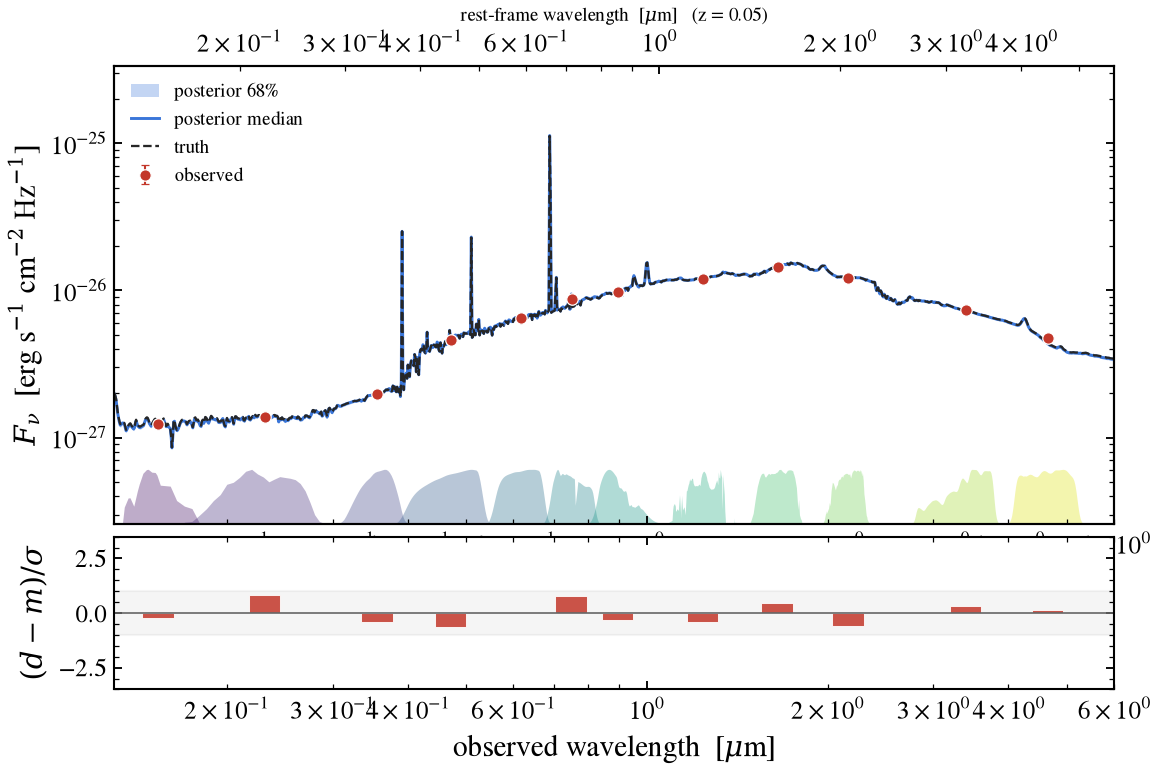

In [9]:
WAVE_OBS = np.geomspace(1300.0, 6e4, 1200)  # 0.13–6 μm covers GALEX → WISE W2
z_truth = float(sed_model._get_redshift(truth))
dl_cm = cosmology.luminosity_distance(z_truth)


def obs_fnu(params):
    pred = sed_model.predict(params)
    lnu_interp = np.interp(
        WAVE_OBS / (1.0 + z_truth), np.asarray(sed_model.wavelengths), np.asarray(pred.rest_sed())
    )
    return np.asarray(lnu_to_fnu(jnp.asarray(lnu_interp), dl_cm, z_truth))


spec_draws = np.stack([obs_fnu(p) for p in draw_dicts(40)])
spec_lo, spec_med, spec_hi = np.percentile(spec_draws, [16, 50, 84], axis=0)
spec_truth = obs_fnu(truth)

# Posterior photometry via ``predict_photometry`` — the same WavePrecomp LUT
# path the fit used. It serves the filter fluxes straight from the SSP × filter
# table without materializing the full-resolution SED cube, so the posterior
# draws map cheaply (no vmap chunking needed).
phot_draws = np.stack([np.asarray(sed_model.predict_photometry(p)) for p in draw_dicts(N_DRAWS)])
phot_med = np.median(phot_draws, axis=0)

fig = plt.figure(figsize=(8.6, 5.4))
gs = fig.add_gridspec(2, 1, height_ratios=[3, 1], hspace=0.04)
ax, ax_res = fig.add_subplot(gs[0]), fig.add_subplot(gs[1])

wave_um = WAVE_OBS / 1e4

# Filter transmission curves are shaded behind the spectrum in the Bagpipes/Prospector style,
# with one viridis color per band.
band_palette = plt.cm.viridis(np.linspace(0.05, 0.95, len(phot.filter_waves)))
ymin, ymax = 0.3 * spec_truth.min(), 3 * spec_truth.max()
for fw, ft, color in zip(phot.filter_waves, phot.filter_trans, band_palette):
    fw_um = np.asarray(fw) / 1e4
    ft_norm = np.asarray(ft) / np.max(ft)
    # Map transmission to the bottom 12 % of the log-y axis.
    band = ymin * (ymax / ymin) ** (0.12 * ft_norm)
    ax.fill_between(fw_um, ymin, band, color=color, alpha=0.35, lw=0)

ax.fill_between(wave_um, spec_lo, spec_hi, color=C_POST, alpha=0.30, lw=0, label="posterior 68%")
ax.plot(wave_um, spec_med, color=C_POST, lw=1.4, label="posterior median")
ax.plot(wave_um, spec_truth, color=C_TRUTH, lw=1.1, ls="--", label="truth")
ax.errorbar(
    wave_eff_um,
    flux_obs,
    yerr=noise,
    fmt="o",
    color=C_DATA,
    ms=5.5,
    capsize=2,
    elinewidth=1.0,
    mec="white",
    mew=0.6,
    label="observed",
    zorder=5,
)
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_ylim(ymin, ymax)
ax.set_xlim(wave_um.min(), wave_um.max())
ax.set_ylabel(r"$F_\nu$  [erg s$^{-1}$ cm$^{-2}$ Hz$^{-1}$]")
ax.legend(frameon=False, fontsize=9, loc="upper left")
plt.setp(ax.get_xticklabels(), visible=False)

# Rest-frame wavelength axis on top.
ax_rest = ax.twiny()
ax_rest.set_xscale("log")
ax_rest.set_xlim(wave_um.min() / (1.0 + z_truth), wave_um.max() / (1.0 + z_truth))
ax_rest.set_xlabel(rf"rest-frame wavelength  [$\mu$m]   (z = {z_truth:.2f})", fontsize=9)

resid = (flux_obs - phot_med) / noise
ax_res.axhspan(-1, 1, alpha=0.08, color="0.5")
ax_res.axhline(0, color="0.4", lw=0.8)
ax_res.bar(
    wave_eff_um,
    resid,
    width=wave_eff_um * 0.12,
    color=C_DATA,
    alpha=0.85,
    edgecolor="white",
    linewidth=0.5,
)
ax_res.set_xscale("log")
ax_res.set_xlim(wave_um.min(), wave_um.max())
ax_res.set_ylim(-3.5, 3.5)
ax_res.set_xlabel(r"observed wavelength  [$\mu$m]")
ax_res.set_ylabel(r"$(d-m)/\sigma$")
fig.savefig(FIG_DIR / "00_posterior_sed.png", dpi=300, bbox_inches="tight")
fig.savefig(FIG_DIR / "00_posterior_sed.pdf", bbox_inches="tight")

## Star-formation history

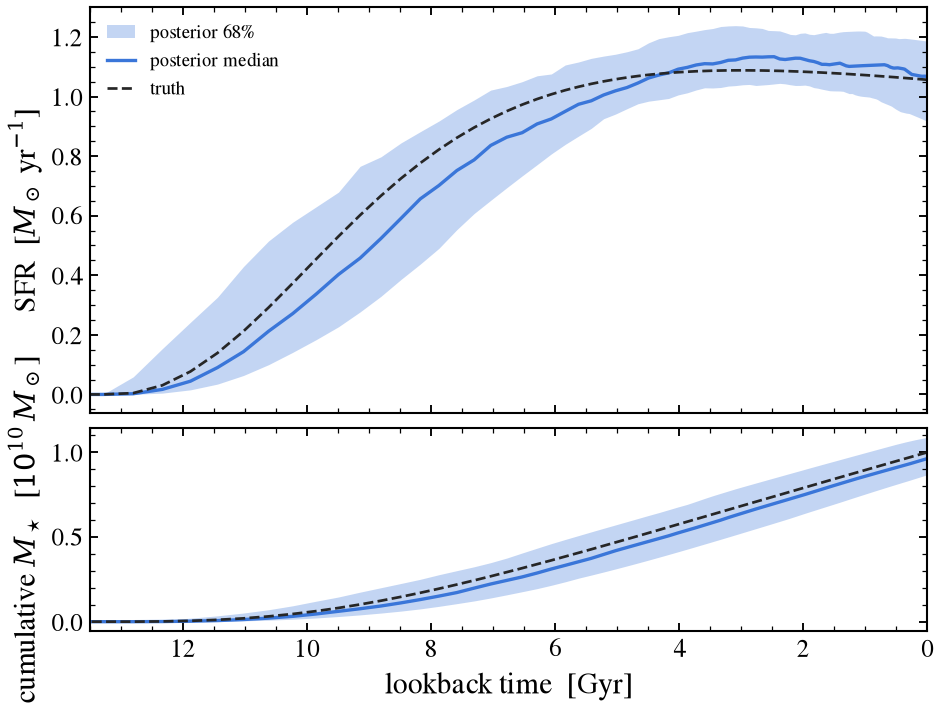

In [10]:
def sfh(p):
    s = sed_model.predict_state(p)
    return (
        np.asarray(s.derived["sfh_grid_lbt_yr"]) / 1e9,
        np.asarray(s.derived["sfr_history"]),
    )


sfr_draws, lbt = [], None
for p in draw_dicts(80):
    lbt_i, sfr_i = sfh(p)
    sfr_draws.append(sfr_i)
    if lbt is None:
        lbt = lbt_i
sfr_draws = np.stack(sfr_draws)
sfr_lo, sfr_med, sfr_hi = np.percentile(sfr_draws, [16, 50, 84], axis=0)
lbt_t, sfr_t = sfh(truth)

# Two-panel SFH: SFR(t) on top, cumulative formed mass on bottom.
fig_sfh, (ax_sfh, ax_cum) = plt.subplots(
    2, 1, figsize=(7.2, 5.4), sharex=True, gridspec_kw=dict(height_ratios=[2, 1], hspace=0.05)
)

ax_sfh.fill_between(lbt, sfr_lo, sfr_hi, color=C_POST, alpha=0.30, lw=0, label="posterior 68%")
ax_sfh.plot(lbt, sfr_med, color=C_POST, lw=1.6, label="posterior median")
ax_sfh.plot(lbt_t, sfr_t, color=C_TRUTH, ls="--", lw=1.3, label="truth")
ax_sfh.set_ylabel(r"SFR  [$M_\odot$ yr$^{-1}$]")
ax_sfh.legend(frameon=False, fontsize=9, loc="upper left")
plt.setp(ax_sfh.get_xticklabels(), visible=False)

# Cumulative formed stellar mass — integrate SFR(t) backwards from now.
dt_yr = np.gradient(lbt * 1e9)  # Gyr → yr, signed
cum_draws = np.flip(np.cumsum(np.flip(sfr_draws * dt_yr[None, :], axis=1), axis=1), axis=1)
cum_lo, cum_med, cum_hi = np.percentile(cum_draws, [16, 50, 84], axis=0)
cum_truth = np.flip(np.cumsum(np.flip(sfr_t * dt_yr), axis=0), axis=0)
ax_cum.fill_between(lbt, cum_lo / 1e10, cum_hi / 1e10, color=C_POST, alpha=0.30, lw=0)
ax_cum.plot(lbt, cum_med / 1e10, color=C_POST, lw=1.6)
ax_cum.plot(lbt_t, cum_truth / 1e10, color=C_TRUTH, ls="--", lw=1.3)
ax_cum.set_ylabel(r"cumulative $M_\star$  [$10^{10}\,M_\odot$]")

for axx in (ax_sfh, ax_cum):
    axx.invert_xaxis()
    axx.set_xlim(13.5, 0)
ax_cum.set_xlabel("lookback time  [Gyr]")

fig_sfh.savefig(FIG_DIR / "00_sfh.png", dpi=300, bbox_inches="tight")
fig_sfh.savefig(FIG_DIR / "00_sfh.pdf", bbox_inches="tight")

## Corner

Free parameters plus derived quantities (`stellar_mass`, `sfr_100myr`,
`sfr_10myr`, in log₁₀), truth dashed.

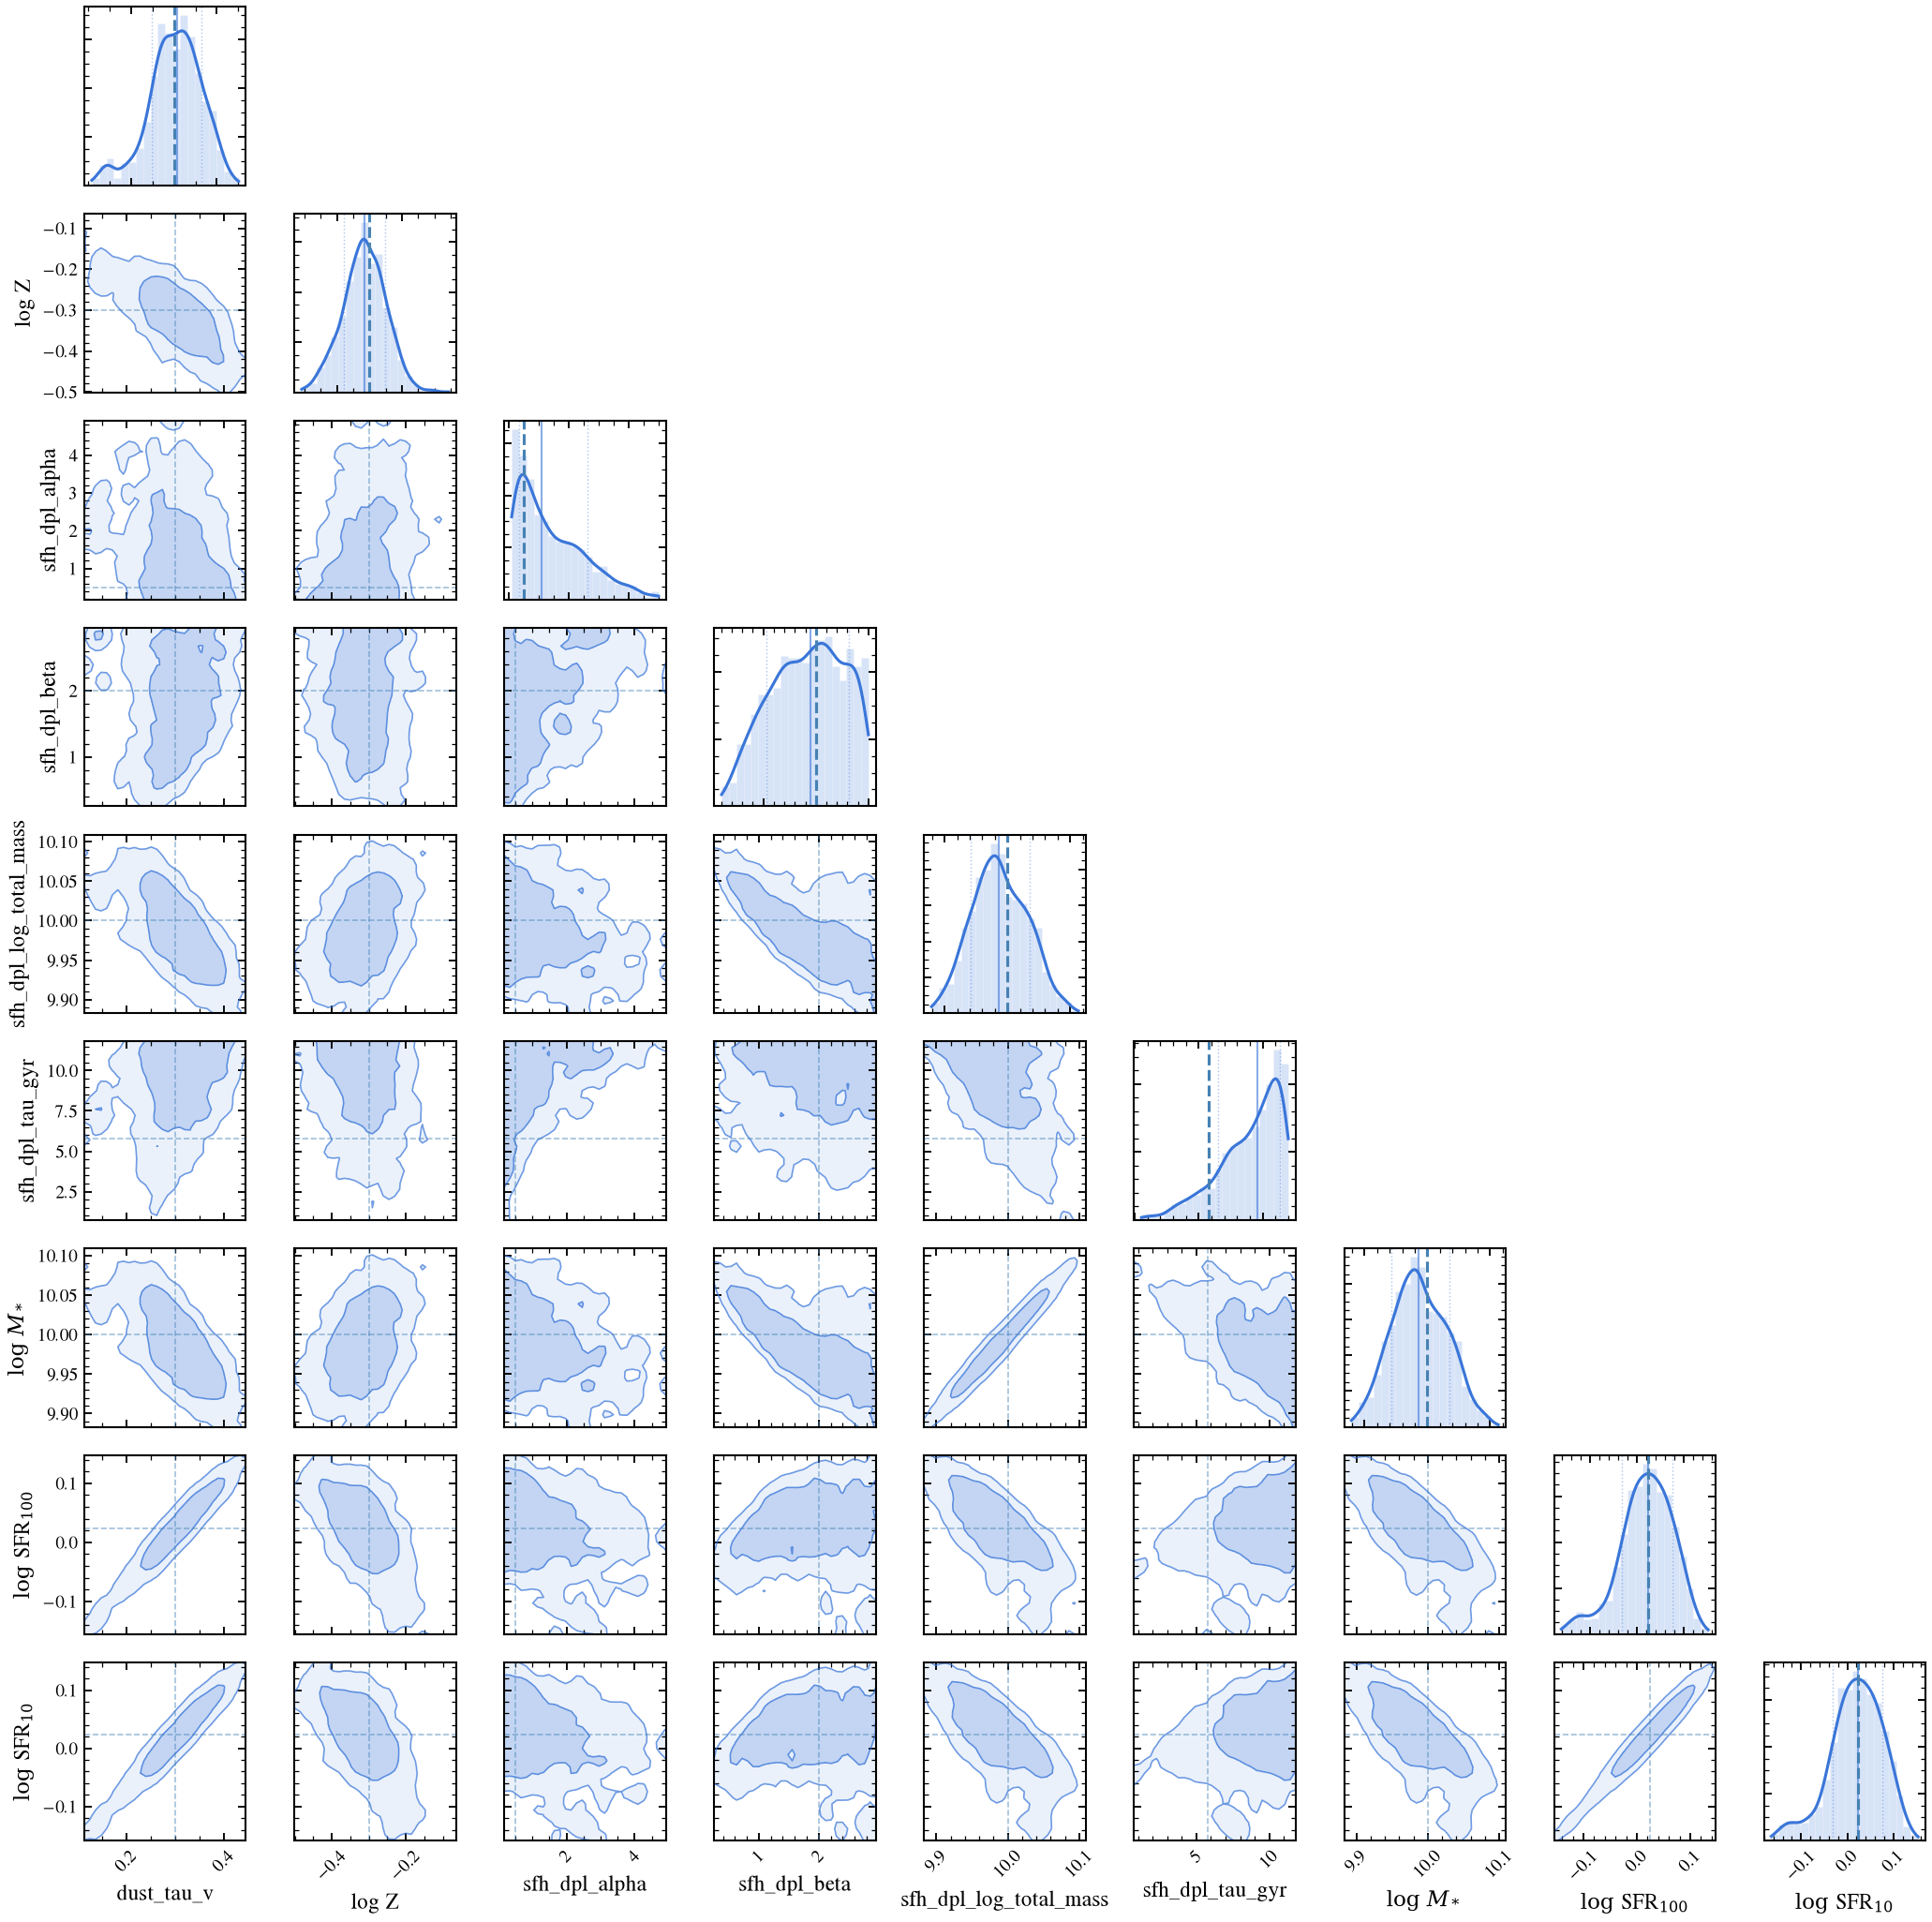

In [11]:
fig_corner = posterior.plot_corner(truths=truth, color=C_POST)
fig_corner.savefig(FIG_DIR / "00_corner.png", dpi=300, bbox_inches="tight")
fig_corner.savefig(FIG_DIR / "00_corner.pdf", bbox_inches="tight")